In [2]:
import pickle
import networkx as nx
import pandas as pd
import geopandas as gpd
import random

#Import network, origins and destinations
with open(r"C:\Users\luca\Downloads\Lux_public_transport_project\multimodal_network.pkl", "rb") as file:
    multimodal_network = pickle.load(file)

pr_stops  = gpd.read_file(r"C:\Users\luca\Downloads\Lux_public_transport_project\PR_stops.gpkg")
cbd_stops = pd.read_csv(r"C:\Users\luca\Downloads\Lux_public_transport_project\district_candidate_stops.csv")

#Reproject to 2169 for any spatial operations
pr_stops = pr_stops.to_crs(epsg=2169)

In [3]:
#===================================
#Validation checks
#===================================

graph_nodes = set(multimodal_network.nodes())
missing_pr  = set(pr_stops["node"])  - graph_nodes
missing_cbd = set(cbd_stops["node"]) - graph_nodes

#FIX: was `and` — only flagged if BOTH sets had missing nodes, silently ignoring one missing set
if missing_pr or missing_cbd:
    print(f"Missing PR nodes:  {missing_pr}")
    print(f"Missing CBD nodes: {missing_cbd}")

#Check PR and CBD groups
print(f"Central Business Districts are: {cbd_stops['FK_QUART_NAME'].unique().tolist()}")
print(f"P+R stations are: {pr_stops['name'].unique().tolist()}")

#Check a random edge has a weight and that it is within a reasonable range
rand_edge = random.choice(list(multimodal_network.edges(data=True)))
u, v, attrs = rand_edge
print(f"Edge goes from {u} to {v} and has attributes {attrs}")
if ("weight" in attrs) and (attrs["weight"] <= 9999):
    print("Edges are reasonable and functional")

Central Business Districts are: ['Gasperich', 'Gare', 'Kirchberg', 'Ville Haute', 'Grund']
P+R stations are: ['Gare', 'Kockelscheuer', 'Hollerich', 'Howald', 'Stadion', 'Héienhaff']
Edge goes from walk_8826249672 to walk_8826249671 and has attributes {'osmid': 953600927, 'highway': 'service', 'oneway': False, 'reversed': False, 'length': 53.72212495957085, 'service': 'parking_aisle', 'edge_type': 'walk', 'mode': 'walk', 'weight': 0.6395491066615578}
Edges are reasonable and functional


In [4]:
import numpy as np

#Group origins and destinations into dictionaries
origin_pr       = pr_stops.groupby("name")["node"].apply(list).to_dict()
destination_cbd = cbd_stops.groupby("FK_QUART_NAME")["node"].apply(list).to_dict()

travel_time_min = {}
for pr, stops in origin_pr.items():

    nodes_stored = {}
    for stop in stops:
        travel_time = nx.single_source_dijkstra_path_length(
            multimodal_network,
            stop,
            cutoff=120,
            weight="weight"
        )

        for node, time in travel_time.items():
            if (node not in nodes_stored) or (time < nodes_stored[node]):
                nodes_stored[node] = time

    travel_time_min[pr] = nodes_stored

# Store [min, mean, max] travel times for each CBD
pr_travel_time = {}

for pr, travel_times in travel_time_min.items():

    pr_travel_time[pr] = {}

    for cbd, cbd_nodes in destination_cbd.items():

        cbd_node_times = [travel_times.get(node, 9999) for node in cbd_nodes]

        reachable = [t for t in cbd_node_times if t != 9999]

        times = [
            np.min(reachable) if reachable else 9999,
            np.mean(reachable) if reachable else 9999,
            np.max(reachable) if reachable else 9999
        ]

        pr_travel_time[pr][cbd] = times

for pr, cbd_dict in pr_travel_time.items():

    cbd_times_reach = [
        [t for t in col if t != 9999]
        for col in zip(*list(cbd_dict.values()))
    ]

    pr_travel_time[pr]["Average Min CBD time"] = np.mean(cbd_times_reach[0]) if cbd_times_reach[0] else 9999
    pr_travel_time[pr]["Average Mean CBD time"] = np.mean(cbd_times_reach[1]) if cbd_times_reach[1] else 9999
    pr_travel_time[pr]["Average Max CBD time"] = np.mean(cbd_times_reach[2]) if cbd_times_reach[2] else 9999

pr_cbd_matrix = (
    pd.DataFrame.from_dict(pr_travel_time, orient="index")
    .reset_index()
    .rename(columns={"index": "P+R Station"})
)

# Heatmap matrix (CBD means only)
cbd_cols = list(destination_cbd.keys())

heatmap_df = pr_cbd_matrix.copy()

for col in cbd_cols:
    heatmap_df[col] = heatmap_df[col].apply(
        lambda x: x[1] if isinstance(x, (list, tuple)) else np.nan
    )

heatmap_df = heatmap_df.set_index("P+R Station")[cbd_cols]



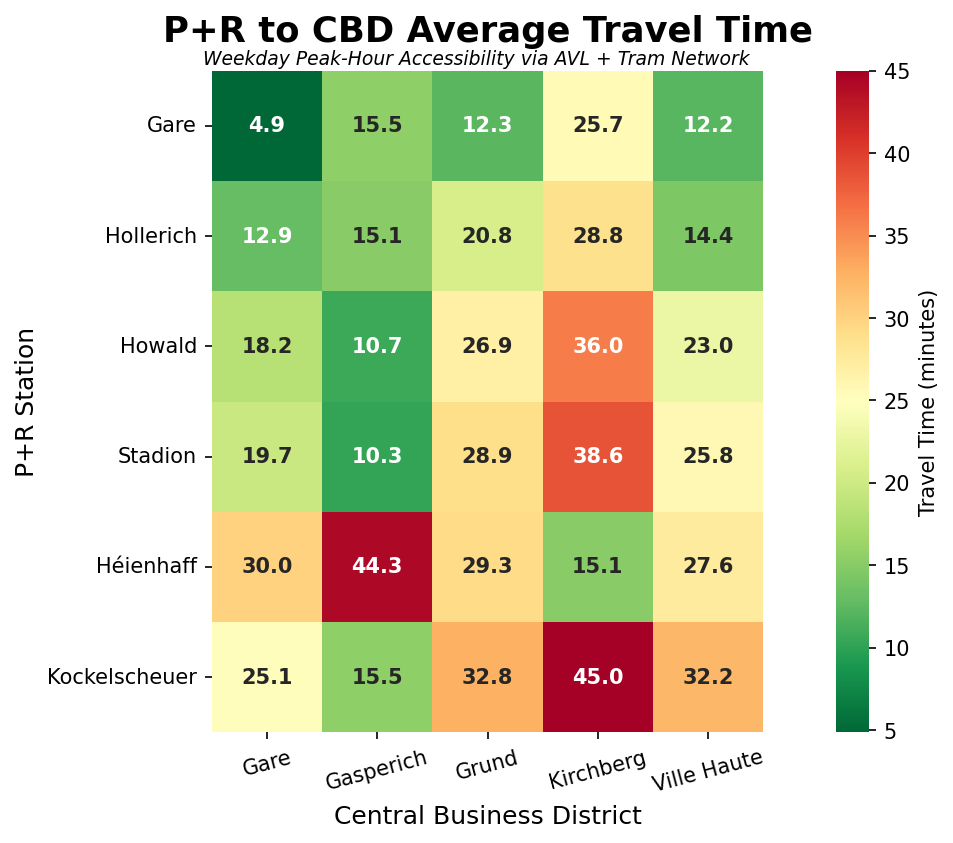

In [5]:
# Heatmap of mean P+R to CBD travel times
import seaborn as sns
import matplotlib.pyplot as plt

plot_matrix = heatmap_df.copy()

row_order = ["Gare", "Hollerich", "Howald", "Stadion", "Héienhaff", "Kockelscheuer"]
plot_matrix = plot_matrix.loc[row_order]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

sns.heatmap(
    plot_matrix,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    square=True,
    cbar_kws={"label": "Travel Time (minutes)"},
    annot_kws={"size": 10, "weight": "bold"},
    ax=ax
)

ax.set_title("P+R to CBD Average Travel Time", fontsize=17, weight="bold", pad=14)
plt.suptitle("Weekday Peak-Hour Accessibility via AVL + Tram Network", fontsize=9, style="italic", y=0.89, x=0.6)
ax.set_xlabel("Central Business District", fontsize=12)
ax.set_ylabel("P+R Station", fontsize=12)

plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


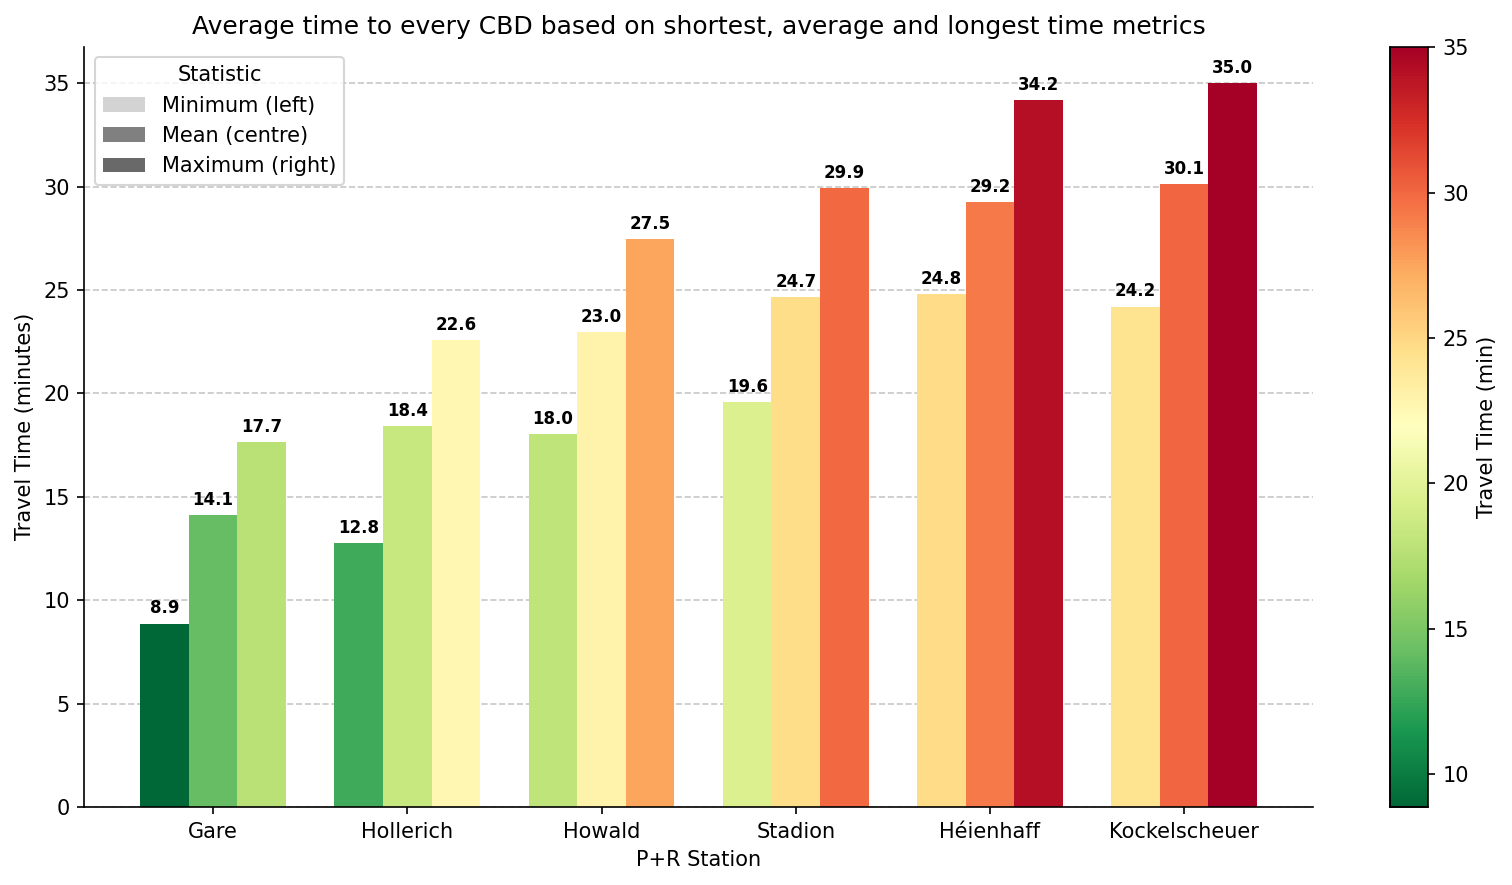

In [12]:
# Grouped min / mean / max accessibility chart
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch

sorted_matrix = pr_cbd_matrix.sort_values(
    "Average Mean CBD time",
    ascending=True
)

stations = sorted_matrix["P+R Station"]

min_times = sorted_matrix["Average Min CBD time"]
mean_times = sorted_matrix["Average Mean CBD time"]
max_times = sorted_matrix["Average Max CBD time"]

x = np.arange(len(stations))
width = 0.25

all_times = np.concatenate([
    min_times.values,
    mean_times.values,
    max_times.values
])

norm = mcolors.Normalize(
    vmin=all_times.min(),
    vmax=all_times.max()
)

colors_min = [cm.RdYlGn_r(norm(v)) for v in min_times]
colors_mean = [cm.RdYlGn_r(norm(v)) for v in mean_times]
colors_max = [cm.RdYlGn_r(norm(v)) for v in max_times]

fig, ax = plt.subplots(figsize=(11, 6), dpi=150)

bars_min = ax.bar(x - width, min_times, width, color=colors_min)
bars_mean = ax.bar(x, mean_times, width, color=colors_mean)
bars_max = ax.bar(x + width, max_times, width, color=colors_max)

for bars in [bars_min, bars_mean, bars_max]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
            weight="bold"
        )

legend_handles = [
    Patch(facecolor="lightgrey", label="Minimum (left)"),
    Patch(facecolor="grey", label="Mean (centre)"),
    Patch(facecolor="dimgray", label="Maximum (right)")
]

ax.legend(handles=legend_handles, title="Statistic")

sm = ScalarMappable(norm=norm, cmap=cm.RdYlGn_r)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Travel Time (min)")

plt.title("Average time to every CBD based on shortest, average and longest time metrics")

ax.set_xticks(x)
ax.set_xticklabels(stations)

ax.set_ylabel("Travel Time (minutes)")
ax.set_xlabel("P+R Station")

ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

sns.despine()

plt.tight_layout()
plt.show()


In [7]:
# Ranking robustness and accessibility threshold checks

ranking_df = pd.DataFrame({
    "Min Rank": (
        pr_cbd_matrix
        .sort_values("Average Min CBD time")
        ["P+R Station"]
        .tolist()
    ),
    "Mean Rank": (
        pr_cbd_matrix
        .sort_values("Average Mean CBD time")
        ["P+R Station"]
        .tolist()
    ),
    "Max Rank": (
        pr_cbd_matrix
        .sort_values("Average Max CBD time")
        ["P+R Station"]
        .tolist()
    )
})

print("Ranking comparison\n")
print(ranking_df)
print()

rank_cols = [
    "Average Min CBD time",
    "Average Mean CBD time",
    "Average Max CBD time"
]

rank_comparison = (
    pr_cbd_matrix
    .set_index("P+R Station")[rank_cols]
    .rank(method="dense")
)

rank_comparison["Mean Rank"] = rank_comparison.mean(axis=1)

print("Mean ranking:\n")
print(rank_comparison["Mean Rank"].sort_values())
print()

print("Mean accessibility for each P+R station\n")

for pr, row in heatmap_df.iterrows():
    under_25 = (row < 25).sum()
    print(f"{pr}: {under_25}/5 districts under 25 min")


Ranking comparison

        Min Rank      Mean Rank       Max Rank
0           Gare           Gare           Gare
1      Hollerich      Hollerich      Hollerich
2         Howald         Howald         Howald
3        Stadion        Stadion        Stadion
4  Kockelscheuer      Héienhaff      Héienhaff
5      Héienhaff  Kockelscheuer  Kockelscheuer

Mean ranking:

P+R Station
Gare             1.000000
Hollerich        2.000000
Howald           3.000000
Stadion          4.000000
Héienhaff        5.333333
Kockelscheuer    5.666667
Name: Mean Rank, dtype: float64

Mean accessibility for each P+R station

Gare: 4/5 districts under 25 min
Hollerich: 4/5 districts under 25 min
Howald: 3/5 districts under 25 min
Héienhaff: 1/5 districts under 25 min
Kockelscheuer: 1/5 districts under 25 min
Stadion: 2/5 districts under 25 min


In [8]:
#Isochrone generation
from shapely.geometry import Point
from shapely.ops import unary_union


time_bands = [15, 20, 30, 45]  # minutes
graph_crs   = multimodal_network.graph["crs"]

#Extract x,y for every node that has coordinates
node_points = {
    node: (data["x"], data["y"])
    for node, data in multimodal_network.nodes(data=True)
    if ("x" in data) and ("y" in data)
}

#For each P+R station build a buffered isochrone per time band
pr_isochrones = {}

for pr, nodes in travel_time_min.items():

    # --- pre-filter nodes once per P+R ---
    valid_nodes = {node: time for node, time in nodes.items() if node in node_points}

    cumulative_iso = {}

    for iso_time in time_bands:
        iso_points = [
            Point(node_points[node])
            for node, time in valid_nodes.items()
            if time <= iso_time
        ]

        if len(iso_points) < 3:
            print(f"  [skip] {pr} @ {iso_time} min — only {len(iso_points)} node(s)")
            continue

        merged = unary_union([p.buffer(150) for p in iso_points])
        merged = merged.buffer(100).buffer(-100)
        merged = merged.simplify(20, preserve_topology=True)

        cumulative_iso[iso_time] = merged

    # --- difference rings ---
    pr_isochrones[pr] = {}
    previous_iso = None

    for iso_time, current_iso in cumulative_iso.items():  # already sorted
        ring = current_iso if previous_iso is None else current_iso.difference(previous_iso)
        pr_isochrones[pr][iso_time] = ring
        previous_iso = current_iso

#When exporting, we have three files: The layers allows you to took look at each isocrhone seperately, atlas combines them all for QGIS atals and the PR copy is also for atlas.

OUTPUT_CRS   = 4326
OUTPUT_GPKG  = {
    "layers"  : "pr_isochrones_layers.gpkg",
    "atlas"   : "pr_isochrones_atlas.gpkg",
    "stops"   : "pr_stops_atlas.gpkg",
}

#Create records out of the isochrones
atlas_records = []
for pr, iso_dict in pr_isochrones.items():
    pr_records = [
        {"pr_name": str(pr), "time_min": iso_time, "geometry": geom}
        for iso_time, geom in iso_dict.items()
    ]
    atlas_records.extend(pr_records)

    #Layer export
    layer_name = str(pr).replace(" ", "_").replace("/", "_")

    (
        gpd.GeoDataFrame(pr_records, geometry="geometry", crs=graph_crs)
        .to_crs(OUTPUT_CRS)
        .to_file(OUTPUT_GPKG["layers"], layer=layer_name, driver="GPKG")
    )

# Combined Atlas isochrone layer
(
    gpd.GeoDataFrame(atlas_records, geometry="geometry", crs=graph_crs)
    .to_crs(OUTPUT_CRS)
    .to_file(OUTPUT_GPKG["atlas"], layer="PR_isochrone_atlas", driver="GPKG")
)

# P+R centroid Atlas layer
pr_stop_records = [
    {"pr_name": pr_name, "geometry": group.geometry.union_all().centroid}
    for pr_name, group in pr_stops.groupby("name")
]
(
    gpd.GeoDataFrame(pr_stop_records, geometry="geometry", crs=pr_stops.crs)
    .to_crs(OUTPUT_CRS)
    .to_file(OUTPUT_GPKG["stops"], layer="PR_stop_atlas", driver="GPKG")
)

print(f"Exported {len(atlas_records)} isochrone features across {len(pr_isochrones)} P+Rs")


Exported 24 isochrone features across 6 P+Rs


In [11]:
# ── Export ─────────────────────────────────────────────────────────────────

# 1. Heatmap — re-run figure and save
plot_matrix = heatmap_df.copy().loc[["Gare", "Hollerich", "Howald", "Stadion", "Héienhaff", "Kockelscheuer"]]
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
sns.heatmap(plot_matrix, annot=True, fmt=".1f", cmap="RdYlGn_r", square=True,
            cbar_kws={"label": "Travel Time (minutes)"}, annot_kws={"size": 10, "weight": "bold"}, ax=ax)
ax.set_title("P+R to CBD Average Travel Time", fontsize=17, weight="bold", pad=14)
plt.suptitle("Weekday Peak-Hour Accessibility via AVL + Tram Network", fontsize=9, style="italic", y=0.89, x=0.6)
ax.set_xlabel("Central Business District", fontsize=12)
ax.set_ylabel("P+R Station", fontsize=12)
plt.xticks(rotation=15); plt.yticks(rotation=0); plt.tight_layout()
fig.savefig("heatmap.png", dpi=300, bbox_inches="tight")
plt.close(); print("✓ heatmap.png")

# 2. Bar chart — re-run figure and save
sorted_matrix = pr_cbd_matrix.sort_values("Average Mean CBD time", ascending=True)
stations, min_times, mean_times, max_times = (sorted_matrix["P+R Station"],
    sorted_matrix["Average Min CBD time"], sorted_matrix["Average Mean CBD time"], sorted_matrix["Average Max CBD time"])
x, width = np.arange(len(stations)), 0.25
all_times = np.concatenate([min_times.values, mean_times.values, max_times.values])
norm = mcolors.Normalize(vmin=all_times.min(), vmax=all_times.max())
colors_min  = [cm.RdYlGn_r(norm(v)) for v in min_times]
colors_mean = [cm.RdYlGn_r(norm(v)) for v in mean_times]
colors_max  = [cm.RdYlGn_r(norm(v)) for v in max_times]
fig, ax = plt.subplots(figsize=(11, 6), dpi=300)
bars_min  = ax.bar(x - width, min_times,  width, color=colors_min)
bars_mean = ax.bar(x,         mean_times, width, color=colors_mean)
bars_max  = ax.bar(x + width, max_times,  width, color=colors_max)
for bars in [bars_min, bars_mean, bars_max]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8, weight="bold")
ax.legend(handles=[Patch(facecolor="lightgrey", label="Minimum (left)"),
                   Patch(facecolor="grey",      label="Mean (centre)"),
                   Patch(facecolor="dimgray",   label="Maximum (right)")], title="Statistic")
sm = ScalarMappable(norm=norm, cmap=cm.RdYlGn_r); sm.set_array([])
fig.colorbar(sm, ax=ax).set_label("Travel Time (min)")
plt.title("Average time to every CBD based on shortest, average and longest time metrics")
ax.set_xticks(x); ax.set_xticklabels(stations)
ax.set_ylabel("Travel Time (minutes)"); ax.set_xlabel("P+R Station")
ax.yaxis.grid(True, linestyle="--", alpha=0.7); ax.set_axisbelow(True)
sns.despine(); plt.tight_layout()
fig.savefig("barchart.png", dpi=300, bbox_inches="tight")
plt.close(); print("✓ barchart.png")

# 3. Ranking table — render DataFrames as matplotlib figure and save
rank_cols = ["Average Min CBD time", "Average Mean CBD time", "Average Max CBD time"]
rank_comparison = pr_cbd_matrix.set_index("P+R Station")[rank_cols].rank(method="dense")
rank_comparison["Mean Rank"] = rank_comparison.mean(axis=1).round(1)


ranking_df = pd.DataFrame({
    "Min Rank":  pr_cbd_matrix.sort_values("Average Min CBD time") ["P+R Station"].tolist(),
    "Mean Rank": pr_cbd_matrix.sort_values("Average Mean CBD time")["P+R Station"].tolist(),
    "Max Rank":  pr_cbd_matrix.sort_values("Average Max CBD time") ["P+R Station"].tolist(),
})

under_25 = pd.DataFrame([
    {"P+R Station": pr, "Districts < 25 min": f"{int((row < 25).sum())}/{len(row)}"}
    for pr, row in heatmap_df.iterrows()
]).sort_values("Districts < 25 min", ascending=False)

fig, axes = plt.subplots(3, 1, figsize=(8, 11), dpi=300)
fig.suptitle("Ranking Robustness & Accessibility Threshold Analysis", fontsize=13, weight="bold", y=0.99)

for ax, df, title in [
    (axes[0], ranking_df,                                              "Station Rankings by Min / Mean / Max Travel Time"),
    (axes[1], rank_comparison[["Mean Rank"]].sort_values("Mean Rank").reset_index(), "Composite Mean Rank Score (lower = more accessible)"),
    (axes[2], under_25,                                                "Districts Reachable Under 25 Minutes"),
]:
    ax.axis("off")
    ax.set_title(title, fontsize=10, weight="bold", pad=6)
    tbl = ax.table(cellText=df.values, colLabels=df.columns, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.6)

plt.tight_layout()
fig.savefig("ranking_table.png", dpi=300, bbox_inches="tight")
plt.close(); print("✓ ranking_table.png")

✓ heatmap.png
✓ barchart.png
✓ ranking_table.png
